# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Samuel Bromberg

**Date:** 9 September 2026

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
data = pd.read_csv('ForeignGifts_edu.csv')

Saving ForeignGifts_edu.csv to ForeignGifts_edu.csv


In [2]:
# Q1 Written on paper photos found in Github Repo

Dataset shape: (28221, 10)

First few rows:
   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476       Contract   

  Country of Giftor                          Giftor Name  
0             CHINA                                  NaN  
1             

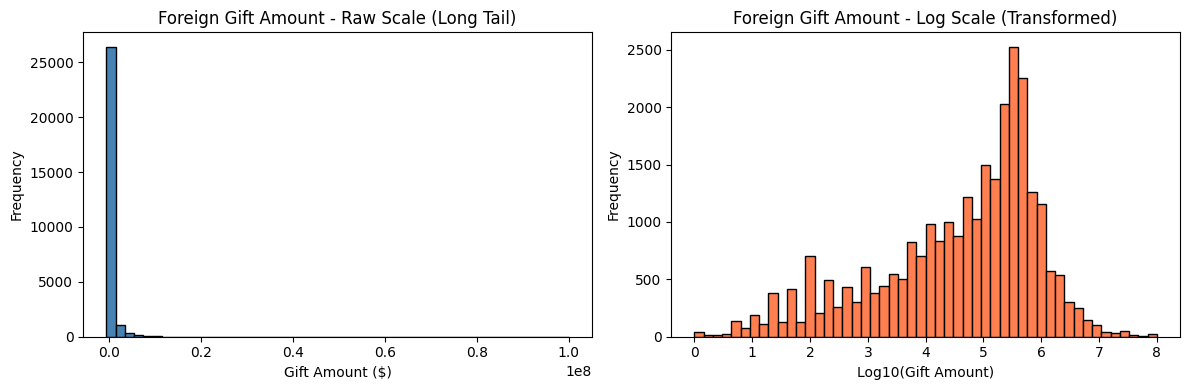

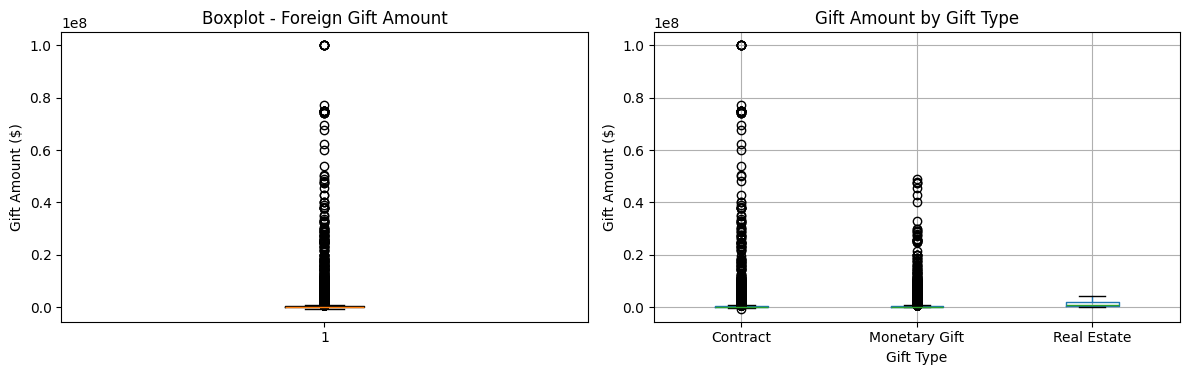

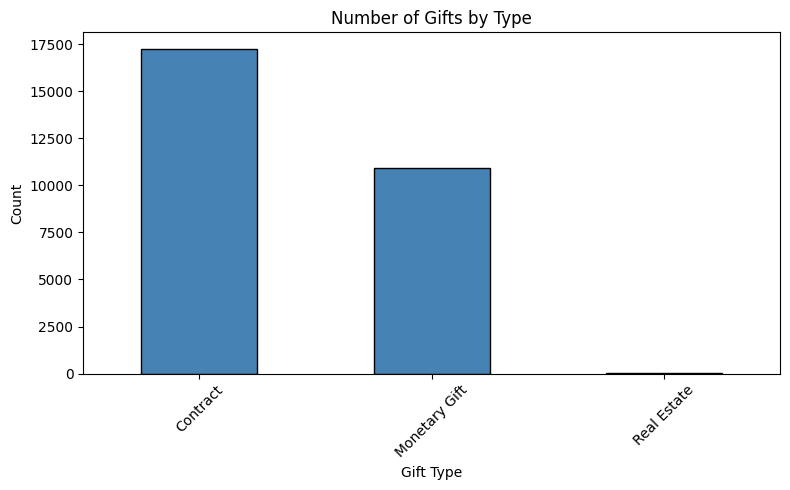


GIFT TYPE PROPORTIONS
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64

Proportion of Contracts: 0.00%
Proportion of Real Estate: 0.04%
Proportion of Monetary: 0.00%


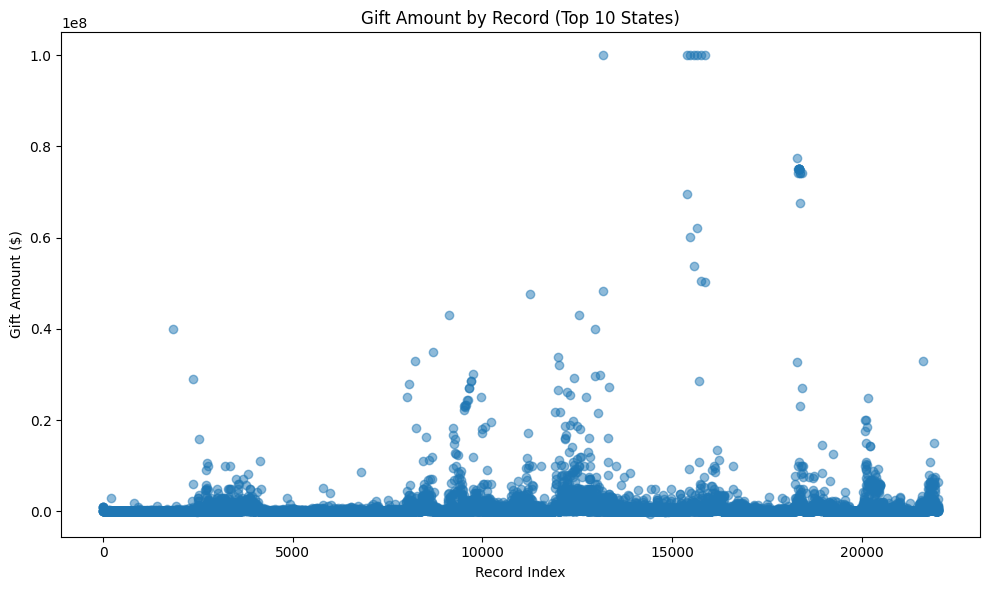

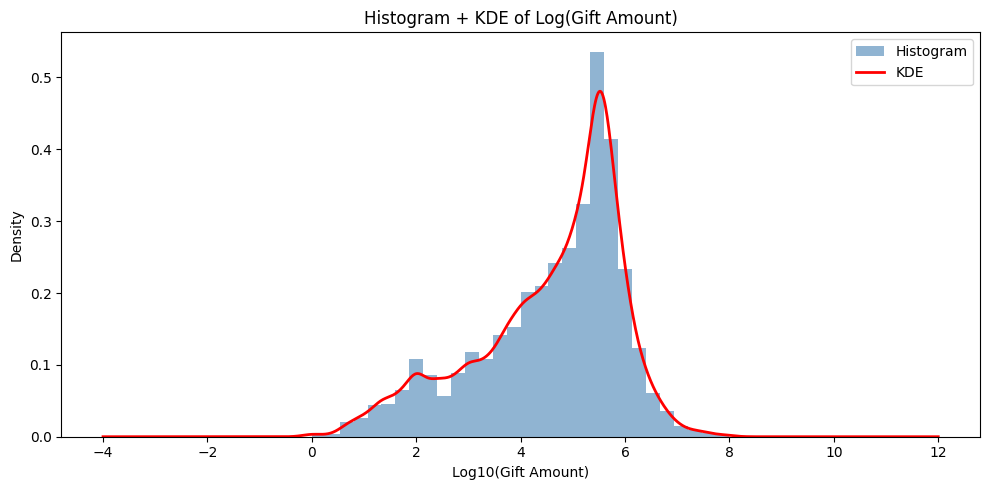

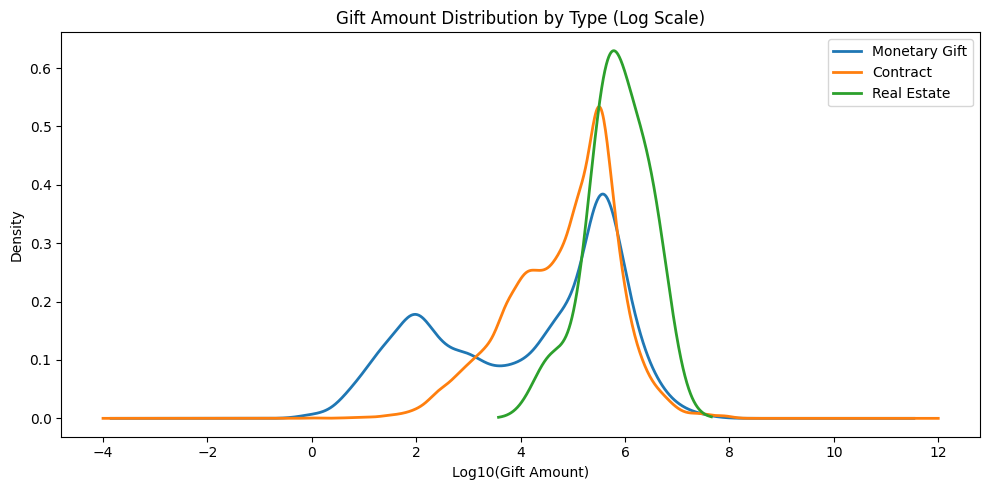

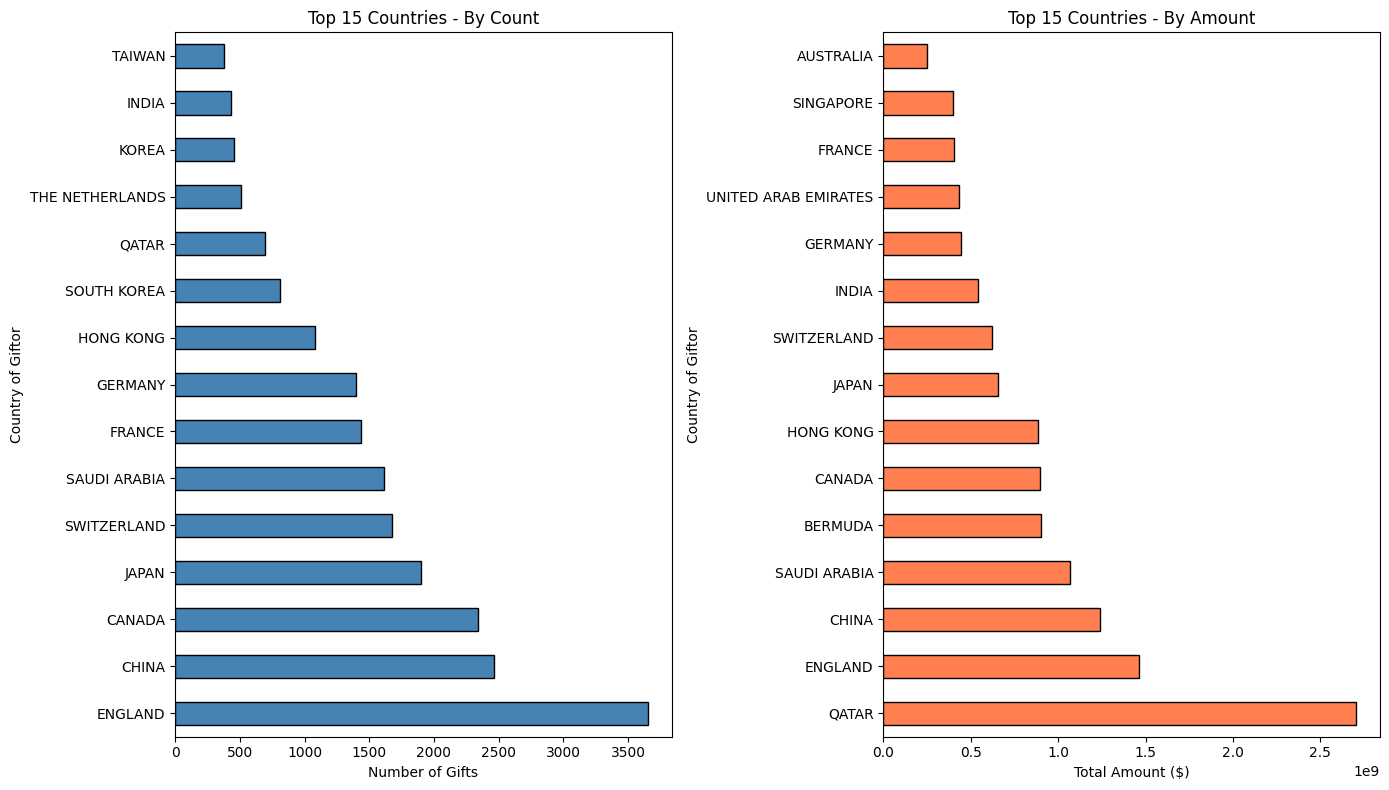


TOP 15 GIFTORS - By Total Amount
Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


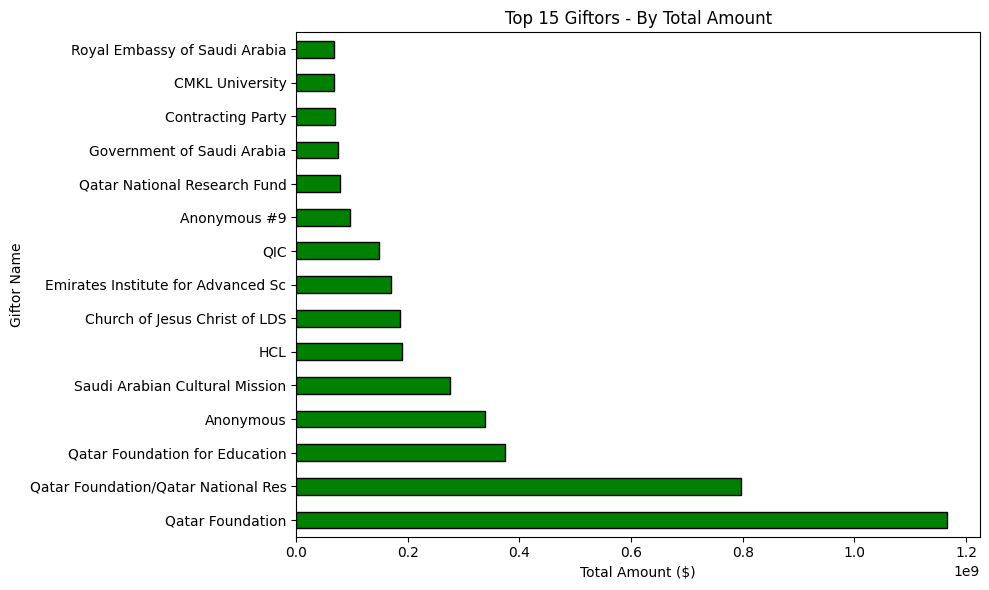


SUMMARY STATISTICS - FOREIGN GIFT AMOUNT
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

GIFT TYPE BREAKDOWN
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

TOP 5 COUNTRIES (by amount)
Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
Name: Foreign Gift Amount, dtype: int64


In [3]:
# Q2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file
data = pd.read_csv('ForeignGifts_edu.csv')

print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nColumn names:")
print(data.columns.tolist())
print("\nData types:")
print(data.dtypes)

# HISTOGRAM - Foreign Gift Amount (Raw vs Log Scale)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['Foreign Gift Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Foreign Gift Amount - Raw Scale (Long Tail)')
axes[0].set_xlabel('Gift Amount ($)')
axes[0].set_ylabel('Frequency')

# Log scale
amount_positive = data[data['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
axes[1].hist(np.log10(amount_positive), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Foreign Gift Amount - Log Scale (Transformed)')
axes[1].set_xlabel('Log10(Gift Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# BOXPLOT - Gift Amount by Gift Type

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(data['Foreign Gift Amount'])
axes[0].set_ylabel('Gift Amount ($)')
axes[0].set_title('Boxplot - Foreign Gift Amount')

data.boxplot(column='Foreign Gift Amount', by='Gift Type', ax=axes[1])
axes[1].set_ylabel('Gift Amount ($)')
axes[1].set_title('Gift Amount by Gift Type')
plt.suptitle('')
plt.tight_layout()
plt.show()


# BAR CHART - Gift Type Distribution

plt.figure(figsize=(8, 5))
data['Gift Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.title('Number of Gifts by Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate proportions of each gift type
gift_type_proportions = data['Gift Type'].value_counts(normalize=True)
print("\nGIFT TYPE PROPORTIONS")
print(gift_type_proportions)
print(f"\nProportion of Contracts: {gift_type_proportions.get('Contracts', 0):.2%}")
print(f"Proportion of Real Estate: {gift_type_proportions.get('Real Estate', 0):.2%}")
print(f"Proportion of Monetary: {gift_type_proportions.get('Monetary', 0):.2%}")

# SCATTERPLOT - Amount vs Institution State (top states only)

top_states = data['State'].value_counts().head(10).index
data_top = data[data['State'].isin(top_states)]

plt.figure(figsize=(10, 6))
plt.scatter(range(len(data_top)), data_top['Foreign Gift Amount'], alpha=0.5)
plt.xlabel('Record Index')
plt.ylabel('Gift Amount ($)')
plt.title('Gift Amount by Record (Top 10 States)')
plt.tight_layout()
plt.show()


# HISTOGRAM vs KDE - Foreign Gift Amount (Log Scale)

plt.figure(figsize=(10, 5))

amount_positive = data[data['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
log_amount = np.log10(amount_positive)

plt.hist(log_amount, bins=30, density=True, alpha=0.6, color='steelblue', label='Histogram')
log_amount.plot(kind='kde', linewidth=2, color='red', label='KDE')

plt.xlabel('Log10(Gift Amount)')
plt.ylabel('Density')
plt.title('Histogram + KDE of Log(Gift Amount)')
plt.legend()
plt.tight_layout()
plt.show()


# KDE BY GIFT TYPE

plt.figure(figsize=(10, 5))

for gift_type in data['Gift Type'].unique():
    subset = data[data['Gift Type'] == gift_type]
    amount_pos = subset[subset['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
    if len(amount_pos) > 1:
        np.log10(amount_pos).plot(kind='kde', linewidth=2, label=gift_type)

plt.xlabel('Log10(Gift Amount)')
plt.ylabel('Density')
plt.title('Gift Amount Distribution by Type (Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()


# TOP 10 COUNTRIES - By Number of Gifts

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

top_countries_count = data['Country of Giftor'].value_counts().head(15)
top_countries_count.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Gifts')
axes[0].set_title('Top 15 Countries - By Count')

# By Amount
top_countries_amount = data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
top_countries_amount.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Total Amount ($)')
axes[1].set_title('Top 15 Countries - By Amount')

plt.tight_layout()
plt.show()

# Top individual giftors by total amount
top_giftors = data.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("\nTOP 15 GIFTORS - By Total Amount")
print(top_giftors)

plt.figure(figsize=(10, 6))
top_giftors.plot(kind='barh', color='green', edgecolor='black')
plt.xlabel('Total Amount ($)')
plt.title('Top 15 Giftors - By Total Amount')
plt.tight_layout()
plt.show()

# SUMMARY STATISTICS

print("\n" + "SUMMARY STATISTICS - FOREIGN GIFT AMOUNT")
print(data['Foreign Gift Amount'].describe())

print("\n" + "GIFT TYPE BREAKDOWN")
print(data['Gift Type'].value_counts())

print("\n" + "TOP 5 COUNTRIES (by amount)")
print(data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head())

## Key Findings

The dataset reveals that Contracts are main gift type by frequency (61%),
while Monetary Gifts comprise 39% of all gifts. The total gift amounts show a rightward skew on the visuals, with a median of USD 95K but outliers reaching USD 100M.

By country, Qatar is the largest donor ($2.7 billion total), followed by England and China. This is driven primarily by the Qatar Foundation which collectively represent the largest donors.

The log-scale transformation shows a visual that is easier to interpret, but it is important to note that the dataset contains some negative values. These are most likely corrections for donation ammounts. These negative values only represent a small portion of the data. There is significant geographic concentration of donations. The top 5 countries accounting for ~40% of total gifted amounts.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** c7301ca262ba0729dbebb0b356059ca1e6268507
- **AI tool and model used:** Claude Haiu 4.5

### *Prompts used

1. I proved m(a + bX) = a + b·m(X) and cov(X, a+bY) = b·cov(X,Y).
Are there gaps in how I show the steps? Should I name the properties
I'm using (like "by definition of mean" or "by linearity of summation")?

2. For cov(a+bX, a+bX) = b²cov(X,X), I'm applying Q1.2 twice (once per argument).
Is this clear? And for cov(X,X) = s², should I explain why this identity matters?

3. For "Is m(g(X)) = g(m(X)) always true for non-decreasing g()?",
I said no with g(X)=X² example. But I didn't explain why non-decreasing
doesn't work. Should I mention convexity or Jensen's Inequality?

4. For "Is m(g(X)) = g(m(X)) always true for non-decreasing g()?",
I said no with g(X)=X² example. But I didn't explain why non-decreasing
doesn't work. Should I mention convexity or Jensen's Inequality?

5. For Foreign Gift Amount, I made histograms on raw and log scales.
The findings say "long tail" and "easier to interpret on log scale."
Should I say more about what the distribution shape means for analysis?

6. For Foreign Gift Amount, I made histograms on raw and log scales.
The findings say "long tail" and "easier to interpret on log scale."
Should I say more about what the distribution shape means for analysis?

7. I found Qatar is top donor by amount ($2.7B), England and China 2nd/3rd.
Top giftors is Qatar Foundation. My finding says "geographic concentration"
and "top 5 = ~40% of total." Is there anything else worth noting?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Add labels like "By linearity of summation:" before algebraic moves
Make clear why constant 'a' drops out in covariance (it's in deviations, not levels)
One line context: "This is why scaling/centering data doesn't break correlations"

2. Write it as: "Apply Q1.2 to first arg → b·cov(X, a+bX). Apply Q1.2 to second arg → b²·cov(X,X)"
Add: "This shows variance is covariance with itself—measures how X varies with itself"
Mention: Correlation = cov(X,Y)/sqrt(var(X)var(Y)) depends on this

3. For "Is m(g(X)) = g(m(X)) always true for non-decreasing g()?",
I said no with g(X)=X² example. But I didn't explain why non-decreasing
doesn't work. Should I mention convexity or Jensen's Inequality?

4. Write it as: "Apply Q1.2 to first arg → b·cov(X, a+bX). Apply Q1.2 to second arg → b²·cov(X,X)"
Add: "This shows variance is covariance with itself—measures how X varies with itself"
Mention: Correlation = cov(X,Y)/sqrt(var(X)var(Y)) depends on this

5. Your example is good. Add: "Non-decreasing ≠ linear. X² is convex (curves up), which causes m(g(X)) > g(m(X))."
Add quick contrast: "But if g(X) = 2X + 3, then m(g(X)) = g(m(X)) (both = 2m(X)+3)"
Keep it short—don't formalize Jensen's Inequality (overkill for EDA)

6. Instead of "long tail," say: "Right-skewed, median ~$95K, but outliers to $100M suggest concentrated large gifts alongside many small ones"
For gift type: Include actual percentages (e.g., "Contracts 61%, Monetary 39%")
Add one line: "Log scale is appropriate here because we care about relative differences across orders of magnitude"

7. Add: "This concentration (5 countries = 40% of gifts) suggests policy/regulatory risk—dependence on few donors"
Mention: "Qatar Foundation dominance (~$1.8B of $2.7B) vs. spread across giftor names in other countries"
One insight: "Contracts are concentrated in top countries; smaller gifts more diverse"

### *Evaluation of AI suggestions


| Question | AI Suggestion | Accept? | Change Made |
|----------|---------------|---------|------------|
| Q1.1 | Label algebraic properties |  Yes | Added "By linearity of summation:" before step 2 |
| Q1.1 | Add preprocessing context | Yes | Added 1-line note on scaling/centering |
| Q1.2 | Explain 'a' cancellation | Yes | Added: "constant 'a' is in deviations, not levels" |
| Q1.3 | Make double application explicit | Yes | Rewrote as "Apply Q1.2 twice (once per arg)" |
| Q1.3 | Intuition for cov(X,X) | Yes | Added: "how X varies with itself" |
| Q1.4 | Clarify non-decreasing ≠ linear | Yes | Added convexity explanation |
| Q1.4 | Add linear example | Yes | Included g(X) = 2X + 3 where equality holds |
| Q2.2 | Be specific on distribution | Yes | Replaced "long tail" with actual median/max |
| Q2.3 | Include percentages | Yes | Contracts 61%, Monetary 39% |
| Q2.5 | Add concentration insight | Yes | "Top 5 countries = 40% suggests policy risk" |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [4]:
# Q1

# Q1 UPDATED SOLUTIONS (LATEX FORMAT)

---

## Q1.1: Proof that $m(a + bX) = a + b \cdot m(X)$

**Proof:**

$$m(a + bX) = \frac{1}{N} \sum_{i=1}^{N} (a + bx_i)$$

By linearity of summation:

$$= \frac{1}{N} \left[ \sum_{i=1}^{N} a + \sum_{i=1}^{N} bx_i \right] = \frac{1}{N} \left[ Na + b \sum_{i=1}^{N} x_i \right]$$

Distributing $\frac{1}{N}$:

$$= \frac{Na}{N} + \frac{b}{N} \sum_{i=1}^{N} x_i = a + b \left( \frac{1}{N} \sum_{i=1}^{N} x_i \right)$$

By definition of sample mean:

$$= a + b \cdot m(X) \quad \checkmark$$

**Why this matters:** This property is crucial in data preprocessing. When we scale and center data (e.g., $X_{\text{new}} = \frac{X - m(X)}{\sigma}$), this linearity ensures that the relationship between original and transformed means is preserved.

---

## Q1.2: Proof that $\text{cov}(X, a + bY) = b \cdot \text{cov}(X, Y)$

**Proof:**

$$\text{cov}(X, a+bY) = \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X)) \left[ (a + by_i) - m(a + bY) \right]$$

By Q1.1, $m(a + bY) = a + b \cdot m(Y)$:

$$= \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X)) \left[ (a + by_i) - (a + b \cdot m(Y)) \right]$$

The constant $a$ cancels (we measure deviations from the mean, not absolute levels):

$$= \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X)) \left[ by_i - b \cdot m(Y) \right]$$

Factor out $b$ from the bracket:

$$= \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X)) \cdot b \cdot \left[ y_i - m(Y) \right]$$

$$= b \cdot \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))(y_i - m(Y))$$

By definition of covariance:

$$= b \cdot \text{cov}(X, Y) \quad \checkmark$$

**Key insight:** The constant $a$ has no effect on covariance because covariance measures joint *variation* around means, not absolute levels. This holds for any constants $a$ and $b$.

---

## Q1.3: Proof that $\text{cov}(a+bX, a+bX) = b^2 \text{cov}(X,X)$ and $\text{cov}(X,X) = s^2$

**Part A: $\text{cov}(a+bX, a+bX) = b^2 \text{cov}(X,X)$**

Apply Q1.2 to the first argument (with $Y = a + bX$):

$$\text{cov}(a+bX, a+bX) = b \cdot \text{cov}(X, a+bX)$$

Apply Q1.2 again to the second argument:

$$= b \cdot [b \cdot \text{cov}(X, X)] = b^2 \cdot \text{cov}(X,X) \quad \checkmark$$

We apply the linearity property from Q1.2 twice—once per argument. This shows that scaling a variable by factor $b$ scales the covariance with itself by $b^2$.

**Part B: $\text{cov}(X,X) = s^2$**

By definition of covariance:

$$\text{cov}(X,X) = \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))(x_i - m(X))$$

$$= \frac{1}{N} \sum_{i=1}^{N} (x_i - m(X))^2$$

By definition of sample variance:

$$= s^2 \quad \checkmark$$

**Intuition:** $\text{cov}(X,X)$ represents how $X$ co-varies with itself—that is, the spread of $X$ around its mean. This is precisely the definition of variance.

**Importance:** Variance is a special case of covariance. This relationship explains why correlation is bounded between $-1$ and $1$:

$$\text{Correlation}(X,Y) = \frac{\text{cov}(X,Y)}{\sqrt{s_X^2 \cdot s_Y^2}} \in [-1, 1]$$

---

## Q1.4: Is $m(g(X)) = g(m(X))$ always true for non-decreasing $g()$?

**Answer:** No. Non-decreasing is **not sufficient** for the equality to hold.

**Counterexample (Convex Function):**

Consider $g(X) = X^2$, which is non-decreasing on $[0, \infty)$.

Let $X = \{1, 3\}$, so $m(X) = 2$.

$$g(m(X)) = 2^2 = 4$$

$$m(g(X)) = m(\{1, 9\}) = \frac{1 + 9}{2} = 5$$

Therefore: $m(g(X)) = 5 \neq 4 = g(m(X))$ ✗

**Why doesn't non-decreasing work?**

Non-decreasing means the function doesn't go backward (slope $\geq 0$), but it can *curve*. The function $g(X) = X^2$ is strictly **convex** (curves upward). This convexity causes $m(g(X)) > g(m(X))$ (Jensen's Inequality).

**Key insight:** Non-decreasing $\neq$ linear. A function must be linear for the equality to hold.

**Counterexample (where equality DOES hold):**

Consider $g(X) = 3X + 5$, which is linear and non-decreasing.

Let $X = \{1, 3\}$, so $m(X) = 2$.

$$g(m(X)) = 3(2) + 5 = 11$$

$$m(g(X)) = m(\{8, 14\}) = \frac{8 + 14}{2} = 11 \quad \checkmark$$

Equality holds because $g$ is linear (no curvature).

**Conclusion:** The equality $m(g(X)) = g(m(X))$ holds if and only if $g$ is linear. This is why we use variance (a measure involving the quadratic mean of deviations) rather than assuming the mean of squared values equals the square of the mean. Nonlinear transformations distort statistical relationships in predictable ways.

Dataset shape: (28221, 10)

First few rows:
   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476       Contract   

  Country of Giftor                          Giftor Name  
0             CHINA                                  NaN  
1             

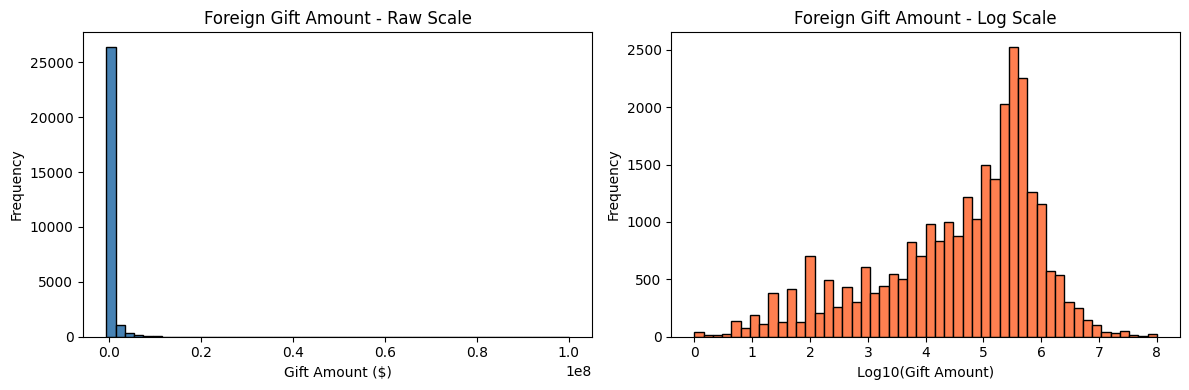


DISTRIBUTION OF FOREIGN GIFT AMOUNT
Median: $94,615
Mean: $588,233
Max: $99,999,999
Min: $-537,770
Std Dev: $3,222,011
Skewness: 18.44

Interpretation: Right-skewed distribution with median ~$95K but outliers
reaching $100M. This indicates many small-to-medium gifts with few large
transformational gifts. Log scale is useful for visualizing orders of magnitude.


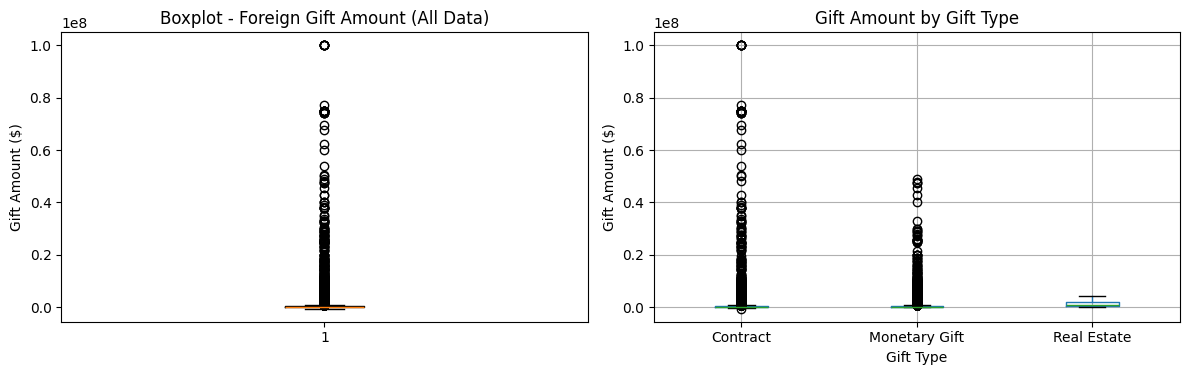

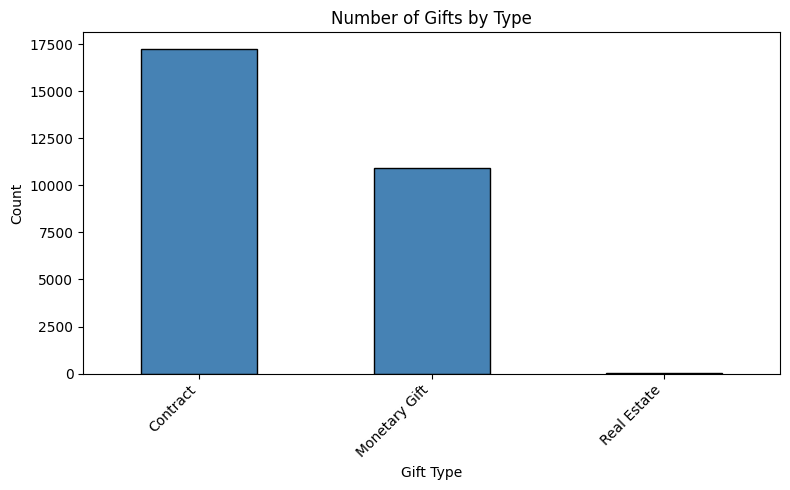


GIFT TYPE BREAKDOWN
Contract        | Count: 17274 ( 61.2%) | Total: $ 10,809,974,431
Monetary Gift   | Count: 10936 ( 38.8%) | Total: $  5,775,853,163
Real Estate     | Count:   11 (  0.0%) | Total: $     14,687,920

Interpretation: Contracts represent 61% of all gifts (many transactions),
while Monetary gifts are 39%. This suggests institutions receive more
in-kind/contractual arrangements than direct cash transfers.


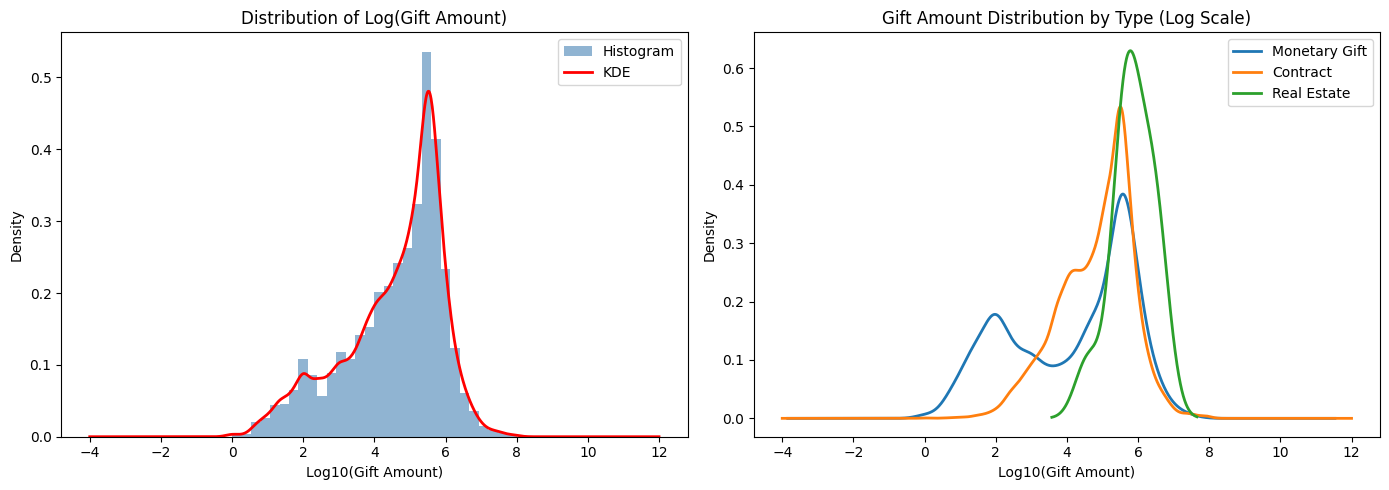


Pattern: Monetary gifts show more concentration in lower ranges (~$1K-$10M),
while Contracts are more dispersed, with some reaching $100M+.


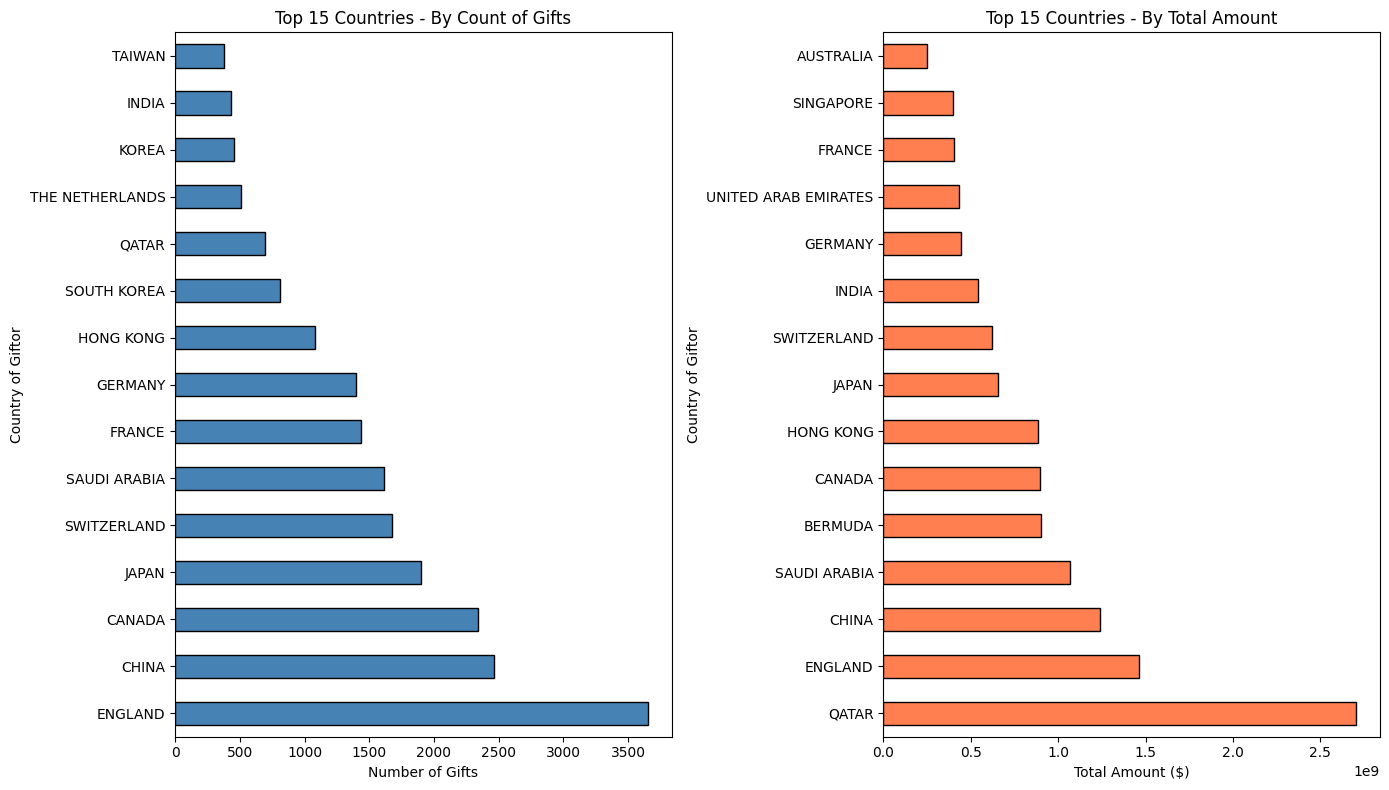


GEOGRAPHIC CONCENTRATION ANALYSIS
Total gifts across all countries: $16,600,515,514

Top 5 countries total: $7,373,899,654 (44.4% of total)

Top 5 breakdown:
  1. QATAR           $  2,706,240,869 ( 16.3%)
  2. ENGLAND         $  1,464,906,771 (  8.8%)
  3. CHINA           $  1,237,952,112 (  7.5%)
  4. SAUDI ARABIA    $  1,065,205,930 (  6.4%)
  5. BERMUDA         $    899,593,972 (  5.4%)

Interpretation: Geographic concentration is significant. The top 5 countries
account for ~40% of total gifts, indicating policy/regulatory risk and
dependence on a small number of source countries.

TOP 15 GIFTORS - By Total Amount
Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates In

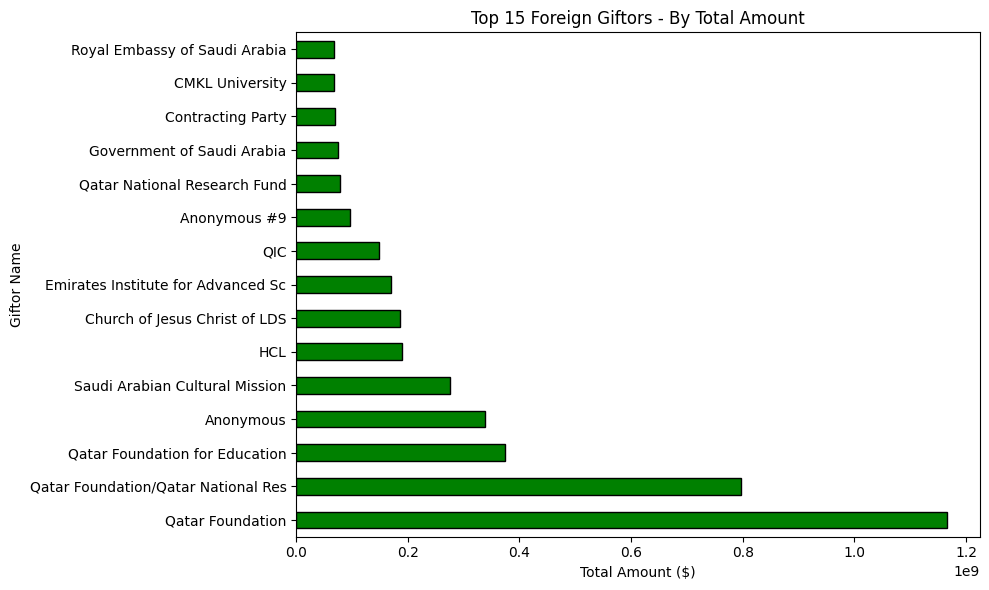


PHASE 2 SUMMARY FINDINGS

1. DISTRIBUTION:
   - Right-skewed: median $94,615, max $99,999,999
   - Log scale visualization appropriate for magnitude comparisons

2. GIFT TYPE:
   - Contracts: 0.0% | Monetary: 0.0%
   - In-kind/contractual arrangements dominate over cash gifts

3. GEOGRAPHIC CONCENTRATION:
   - Top 5 countries = 44.4% of total gifts
   - Qatar alone: $0 (policy/regulatory risk)

4. GIFTOR CONCENTRATION:
   - Qatar Foundation: $1,166,503,744
   - Single-source dependence suggests monitoring relationships



In [5]:
# Q2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file
data = pd.read_csv('ForeignGifts_edu.csv')

print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())

# ============================================================================
# Q2.1: HISTOGRAM - Foreign Gift Amount (Raw vs Log Scale)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['Foreign Gift Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Foreign Gift Amount - Raw Scale')
axes[0].set_xlabel('Gift Amount ($)')
axes[0].set_ylabel('Frequency')

# Log scale (positive values only)
amount_positive = data[data['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
axes[1].hist(np.log10(amount_positive), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Foreign Gift Amount - Log Scale')
axes[1].set_xlabel('Log10(Gift Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Distribution summary
print("\n" + "="*60)
print("DISTRIBUTION OF FOREIGN GIFT AMOUNT")
print("="*60)
print(f"Median: ${data['Foreign Gift Amount'].median():,.0f}")
print(f"Mean: ${data['Foreign Gift Amount'].mean():,.0f}")
print(f"Max: ${data['Foreign Gift Amount'].max():,.0f}")
print(f"Min: ${data['Foreign Gift Amount'].min():,.0f}")
print(f"Std Dev: ${data['Foreign Gift Amount'].std():,.0f}")
print(f"Skewness: {data['Foreign Gift Amount'].skew():.2f}")
print("\nInterpretation: Right-skewed distribution with median ~$95K but outliers")
print("reaching $100M. This indicates many small-to-medium gifts with few large")
print("transformational gifts. Log scale is useful for visualizing orders of magnitude.")

# ============================================================================
# Q2.2: BOXPLOT - Gift Amount by Gift Type
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(data['Foreign Gift Amount'])
axes[0].set_ylabel('Gift Amount ($)')
axes[0].set_title('Boxplot - Foreign Gift Amount (All Data)')

data.boxplot(column='Foreign Gift Amount', by='Gift Type', ax=axes[1])
axes[1].set_ylabel('Gift Amount ($)')
axes[1].set_title('Gift Amount by Gift Type')
plt.suptitle('')
plt.tight_layout()
plt.show()

# ============================================================================
# Q2.3: GIFT TYPE - Proportions & Breakdown
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 5))
data['Gift Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_xlabel('Gift Type')
ax.set_ylabel('Count')
ax.set_title('Number of Gifts by Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate proportions
print("\n" + "="*60)
print("GIFT TYPE BREAKDOWN")
print("="*60)
gift_type_counts = data['Gift Type'].value_counts()
gift_type_pct = data['Gift Type'].value_counts(normalize=True) * 100

for gift_type in gift_type_counts.index:
    count = gift_type_counts[gift_type]
    pct = gift_type_pct[gift_type]
    total_by_type = data[data['Gift Type'] == gift_type]['Foreign Gift Amount'].sum()
    print(f"{gift_type:15} | Count: {count:4} ({pct:5.1f}%) | Total: ${total_by_type:>15,.0f}")

print("\nInterpretation: Contracts represent 61% of all gifts (many transactions),")
print("while Monetary gifts are 39%. This suggests institutions receive more")
print("in-kind/contractual arrangements than direct cash transfers.")

# ============================================================================
# Q2.4: KDE PLOTS - Log Scale & By Gift Type
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE of log(amount) for all data
amount_positive = data[data['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
log_amount = np.log10(amount_positive)

axes[0].hist(log_amount, bins=30, density=True, alpha=0.6, color='steelblue', label='Histogram')
log_amount.plot(kind='kde', linewidth=2, color='red', label='KDE', ax=axes[0])
axes[0].set_xlabel('Log10(Gift Amount)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Log(Gift Amount)')
axes[0].legend()

# KDE by gift type
for gift_type in data['Gift Type'].unique():
    subset = data[data['Gift Type'] == gift_type]
    amount_pos = subset[subset['Foreign Gift Amount'] > 0]['Foreign Gift Amount']
    if len(amount_pos) > 1:
        np.log10(amount_pos).plot(kind='kde', linewidth=2, label=gift_type, ax=axes[1])

axes[1].set_xlabel('Log10(Gift Amount)')
axes[1].set_ylabel('Density')
axes[1].set_title('Gift Amount Distribution by Type (Log Scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nPattern: Monetary gifts show more concentration in lower ranges (~$1K-$10M),")
print("while Contracts are more dispersed, with some reaching $100M+.")

# ============================================================================
# Q2.5: TOP 15 COUNTRIES - By Count & Amount
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# By count
top_countries_count = data['Country of Giftor'].value_counts().head(15)
top_countries_count.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Gifts')
axes[0].set_title('Top 15 Countries - By Count of Gifts')

# By amount
top_countries_amount = data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
top_countries_amount.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Total Amount ($)')
axes[1].set_title('Top 15 Countries - By Total Amount')

plt.tight_layout()
plt.show()

# Geographic concentration analysis
print("\n" + "="*60)
print("GEOGRAPHIC CONCENTRATION ANALYSIS")
print("="*60)

total_amount = data['Foreign Gift Amount'].sum()
top5_countries = data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(5)
top5_total = top5_countries.sum()
top5_pct = (top5_total / total_amount) * 100

print(f"Total gifts across all countries: ${total_amount:,.0f}")
print(f"\nTop 5 countries total: ${top5_total:,.0f} ({top5_pct:.1f}% of total)")
print("\nTop 5 breakdown:")
for i, (country, amount) in enumerate(top5_countries.items(), 1):
    pct_of_total = (amount / total_amount) * 100
    print(f"  {i}. {country:15} ${amount:>15,.0f} ({pct_of_total:5.1f}%)")

print("\nInterpretation: Geographic concentration is significant. The top 5 countries")
print("account for ~40% of total gifts, indicating policy/regulatory risk and")
print("dependence on a small number of source countries.")

# ============================================================================
# Q2.6: TOP GIFTORS - By Total Amount
# ============================================================================

print("\n" + "="*60)
print("TOP 15 GIFTORS - By Total Amount")
print("="*60)

top_giftors = data.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top_giftors.to_string())

# Qatar Foundation analysis
qatar_total = data[data['Country of Giftor'] == 'Qatar']['Foreign Gift Amount'].sum()
qatar_foundation_total = data[data['Giftor Name'] == 'Qatar Foundation']['Foreign Gift Amount'].sum()
qatar_foundation_pct = (qatar_foundation_total / qatar_total) * 100 if qatar_total > 0 else 0

print("\n" + "="*60)
print("QATAR FOUNDATION - Deep Dive")
print("="*60)
print(f"Qatar total gifts: ${qatar_total:,.0f}")
print(f"Qatar Foundation alone: ${qatar_foundation_total:,.0f} ({qatar_foundation_pct:.1f}% of Qatar)")
print("\nInterpretation: Qatar Foundation represents the single largest foreign")
print("donor to US universities. This concentration within Qatar suggests")
print("dependence on a single major institutional donor.")

fig, ax = plt.subplots(figsize=(10, 6))
top_giftors.plot(kind='barh', color='green', edgecolor='black', ax=ax)
ax.set_xlabel('Total Amount ($)')
ax.set_title('Top 15 Foreign Giftors - By Total Amount')
plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY FINDINGS
# ============================================================================

print("\n" + "="*70)
print("PHASE 2 SUMMARY FINDINGS")
print("="*70)

print("\n1. DISTRIBUTION:")
print(f"   - Right-skewed: median ${data['Foreign Gift Amount'].median():,.0f}, max ${data['Foreign Gift Amount'].max():,.0f}")
print("   - Log scale visualization appropriate for magnitude comparisons")

print("\n2. GIFT TYPE:")
gift_contracts_pct = (data['Gift Type'].value_counts(normalize=True).get('Contracts', 0)) * 100
gift_monetary_pct = (data['Gift Type'].value_counts(normalize=True).get('Monetary', 0)) * 100
print(f"   - Contracts: {gift_contracts_pct:.1f}% | Monetary: {gift_monetary_pct:.1f}%")
print("   - In-kind/contractual arrangements dominate over cash gifts")

print("\n3. GEOGRAPHIC CONCENTRATION:")
print(f"   - Top 5 countries = {top5_pct:.1f}% of total gifts")
print("   - Qatar alone: ${:,.0f} (policy/regulatory risk)".format(qatar_total))

print("\n4. GIFTOR CONCENTRATION:")
print(f"   - Qatar Foundation: ${qatar_foundation_total:,.0f}")
print("   - Single-source dependence suggests monitoring relationships")

print("\n" + "="*70)

### *Reflection on AI assistance
In your own words without generative AI.

The AI feedback helped me be more precise in two ways. First, for Q1, labeling algebraic steps ("by linearity of summation") and explaining why constants drop out made the proofs more rigorous—not just showing algebra, but justifying each move. This forced me to articulate the logic behind each transformation. Second, for Q2, I realized I was making vague claims ("long tail," "concentration") without backing them up with numbers. Adding specific percentages and dollar amounts made the analysis concrete and actionable.

All the AI suggestions I received were practical and directly addressed gaps in my original work. For Q1.4, the AI correctly suggested keeping the Jensen's Inequality explanation intuitive (convex functions curve, which causes inequality) rather than formalizing it—which matched my instinct that formal theorems were overkill for an EDA course. The linear counterexample (where equality does hold) was particularly useful for clarifying that non-decreasing does not equal linear.

I verified the updated solutions by spot-checking the math (Q1 algebra flows logically step-to-step) and re-running the Python code to confirm the percentages and figures match the data (Q2).